# ДЗ-2: DEER — Label-Guided In-Context Learning for NER

**Статья:** Bai, Hassanzadeh, Saeedi, Dredze. *LLMs are Better Than You Think:
Label-Guided In-Context Learning for Named Entity Recognition*, EMNLP 2025
(arXiv: 2505.23722, код авторов: https://github.com/bflashcp3f/deer)

> Отличия от оригинала (доступность в Colab без API-ключей): LLM —
> **Qwen2.5-3B-Instruct** локально (в статье Qwen2.5-7B / Llama3.3-70B / GPT-4o);
> эмбеддинги — all-MiniLM-L6-v2 (в статье text-embedding-3-small).
> Гиперпараметры — из статьи: $\lambda_1=\lambda_2=1,\ w_e=w_c=1,\ w_o=0.01$, окно 2.

In [ ]:
import sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U",
                    "sentence-transformers", "accelerate"], check=True)

import os, re, json, math, time, random
from collections import Counter, defaultdict
from dataclasses import dataclass, field
import numpy as np
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device = {DEVICE}")
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0),
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


@dataclass
class Config:
    dataset: str = "wnut17"
    llm_name: str = "Qwen/Qwen2.5-3B-Instruct"
    embed_name: str = "sentence-transformers/all-MiniLM-L6-v2"
    n_train_pool: int = 4000
    n_test: int = 100
    n_demos: int = 8
    n_span_demos: int = 4
    ctx_window: int = 2
    lam1: float = 1.0; lam2: float = 1.0
    w_e: float = 1.0; w_c: float = 1.0; w_o: float = 0.01
    fn_threshold: float = 0.5
    fn_min_count: int = 3
    unseen_nb_threshold: float = 0.5
    max_reflections: int = 6
    max_new_tokens: int = 320
    fast_dev_run: bool = False

cfg = Config()
if cfg.fast_dev_run:
    cfg.n_test, cfg.n_train_pool = 20, 1000
print(cfg)

device = cuda
Tesla T4 15.6 GB
Config(dataset='wnut17', llm_name='Qwen/Qwen2.5-3B-Instruct', embed_name='sentence-transformers/all-MiniLM-L6-v2', n_train_pool=4000, n_test=100, n_demos=8, n_span_demos=4, ctx_window=2, lam1=1.0, lam2=1.0, w_e=1.0, w_c=1.0, w_o=0.01, fn_threshold=0.5, fn_min_count=3, unseen_nb_threshold=0.5, max_reflections=6, max_new_tokens=320, fast_dev_run=False)


In [ ]:
import urllib.request

WNUT_BASE = "https://raw.githubusercontent.com/leondz/emerging_entities_17/master/"
WNUT_FILES = {"train": "wnut17train.conll", "dev": "emerging.dev.conll",
              "test": "emerging.test.annotated"}

TYPE_NAMES = {"person": "person name", "location": "location or venue",
              "corporation": "corporation or company",
              "product": "product (tangible or software)",
              "creative-work": "creative work (song, movie, book, TV show)",
              "group": "group (band, sports team, non-corporate org)"}
ENTITY_TYPES = sorted(TYPE_NAMES)

def bio_to_entities(tokens, labels):
    """BIO-метки (строки) -> сущности [{'name','type'}] и индексы их токенов."""
    ents, spans, cur, cur_t, cur_idx = [], [], [], None, []
    def flush():
        nonlocal cur, cur_t, cur_idx
        if cur:
            ents.append({"name": " ".join(cur), "type": cur_t})
            spans.append(cur_idx)
        cur, cur_t, cur_idx = [], None, []
    for i, (tok, lab) in enumerate(zip(tokens, labels)):
        if lab.startswith("B-") or (lab.startswith("I-") and cur_t != lab[2:]):
            flush(); cur, cur_t, cur_idx = [tok], lab[2:], [i]
        elif lab.startswith("I-") and cur_t == lab[2:]:
            cur.append(tok); cur_idx.append(i)
        else:
            flush()
    flush()
    return ents, spans

def load_wnut(split):
    txt = urllib.request.urlopen(WNUT_BASE + WNUT_FILES[split],
                                 timeout=60).read().decode("utf-8", "ignore")
    data, toks, labs = [], [], []
    for line in txt.splitlines() + [""]:
        line = line.rstrip()
        if not line:
            if len(toks) >= 3:
                ents, spans = bio_to_entities(toks, labs)
                data.append({"tokens": toks, "text": " ".join(toks),
                             "entities": ents, "spans": spans})
            toks, labs = [], []
            continue
        parts = line.split("\t")
        toks.append(parts[0]); labs.append(parts[-1].strip())
    return data

train_pool = load_wnut("train")[:cfg.n_train_pool]
_test_all = load_wnut("test")
random.Random(SEED).shuffle(_test_all)
test_data = _test_all[:cfg.n_test]

train_vocab = {t.lower() for ex in train_pool for t in ex["tokens"]}
unseen = [t for ex in test_data for t in ex["tokens"] if t.lower() not in train_vocab]
n_tok = sum(len(ex["tokens"]) for ex in test_data)
print(f"train pool: {len(train_pool)}, test: {len(test_data)}, типы: {ENTITY_TYPES}")
print(f"unseen-токенов в тесте: {len(unseen)}/{n_tok} ({len(unseen)/n_tok*100:.0f}%) "
      "-> хороший режим для error reflection")
print("пример:", test_data[0]["text"][:90], "->", test_data[0]["entities"])

train pool: 3385, test: 100, типы: ['corporation', 'creative-work', 'group', 'location', 'person', 'product']
unseen-токенов в тесте: 350/1922 (18%) -> хороший режим для error reflection
пример: 2017 , 03 , 18 06 : 30 : 05 jay dmb test 8 - 11 - 2016 -> []


In [ ]:
def norm_tok(t):
    return t.lower()

PUNCT = set(".,:;!?()'\"`-—–&/")

class TokenStats:
    """P(entity), P(context), P(other) для каждого токена train-корпуса +
    span-примеры для error reflection."""
    def __init__(self, data, window):
        cnt = defaultdict(lambda: np.zeros(3))
        ent_spans = defaultdict(list)
        ctx_spans = defaultdict(list)
        oth_spans = defaultdict(list)
        ent_type_cnt = defaultdict(Counter)
        for ex in data:
            toks, L = ex["tokens"], len(ex["tokens"])
            role = ["o"] * L
            for span in ex["spans"]:
                for i in span:
                    role[i] = "e"
            for span in ex["spans"]:
                lo, hi = span[0], span[-1]
                for i in range(max(0, lo - window), min(L, hi + window + 1)):
                    if role[i] == "o":
                        role[i] = "c"
            for span, ent in zip(ex["spans"], ex["entities"]):
                lo, hi = span[0], span[-1]
                s_txt = " ".join(toks[max(0, lo - window):min(L, hi + window + 1)])
                for i in span:
                    ent_spans[norm_tok(toks[i])].append((s_txt, ent["name"], ent["type"]))
                    ent_type_cnt[norm_tok(toks[i])][ent["type"]] += 1
                for i in range(max(0, lo - window), min(L, hi + window + 1)):
                    if i < lo or i > hi:
                        ctx_spans[norm_tok(toks[i])].append((s_txt, ent["name"], ent["type"]))
            for i in range(L):
                t = norm_tok(toks[i])
                cnt[t]["eco".index(role[i])] += 1
                if role[i] == "o":
                    oth_spans[t].append(" ".join(toks[max(0, i - window):i + window + 1]))
        self.prob, self.count = {}, {}
        for t, v in cnt.items():
            self.count[t] = v
            self.prob[t] = v / v.sum()
        self.ent_spans, self.ctx_spans, self.oth_spans = ent_spans, ctx_spans, oth_spans
        self.ent_type_cnt = ent_type_cnt

    def P(self, tok):
        return self.prob.get(norm_tok(tok))

    def W(self, tok, cfg):
        p = self.P(tok)
        if p is None:
            return 1.0
        return cfg.w_e * p[0] + cfg.w_c * p[1] + cfg.w_o * p[2]

stats = TokenStats(train_pool, cfg.ctx_window)
top_ent = sorted(stats.prob, key=lambda t: -stats.count[t][0])[:10]
print("топ entity-токенов:", [(t, int(stats.count[t][0]), round(stats.prob[t][0], 2))
                              for t in top_ent])

топ entity-токенов: [('the', 67, np.float64(0.05)), ('twitter', 37, np.float64(1.0)), ('justin', 27, np.float64(0.93)), ('of', 21, np.float64(0.04)), ('bieber', 19, np.float64(1.0)), ('facebook', 14, np.float64(1.0)), ('pope', 14, np.float64(1.0)), ('lohan', 13, np.float64(1.0)), ('youtube', 13, np.float64(0.93)), ('.', 12, np.float64(0.01))]


In [ ]:
from sentence_transformers import SentenceTransformer

_embedder = SentenceTransformer(cfg.embed_name, device=DEVICE)

def embed_tokens_batch(list_of_token_lists):
    outs = []
    for toks in list_of_token_lists:
        vecs = _embedder.encode(toks, convert_to_numpy=True,
                                show_progress_bar=False, batch_size=256)
        outs.append(vecs)
    return outs

def embed_sentences(texts):
    return _embedder.encode(texts, convert_to_numpy=True,
                            show_progress_bar=False, batch_size=128)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def build_retrieval_index():
    print("кэшируем эмбеддинги train-пула...")
    sent_emb = embed_sentences([ex["text"] for ex in train_pool])
    tok_embs = embed_tokens_batch([ex["tokens"] for ex in train_pool])
    weighted = np.stack([
        (np.array([stats.W(t, cfg) for t in ex["tokens"]])[:, None] * te).sum(0)
        for ex, te in zip(train_pool, tok_embs)])
    token_sets = [set(map(norm_tok, ex["tokens"])) for ex in train_pool]
    return {"sent": sent_emb / (np.linalg.norm(sent_emb, axis=1, keepdims=True) + 1e-9),
            "wvec": weighted / (np.linalg.norm(weighted, axis=1, keepdims=True) + 1e-9),
            "tok_sets": token_sets}

INDEX = build_retrieval_index()

def retrieve(query_ex, method, k):
    if method == "random":
        rng = random.Random(hash(query_ex["text"]) & 0xFFFF)
        return rng.sample(range(len(train_pool)), k)
    if method == "kate":
        qv = embed_sentences([query_ex["text"]])[0]
        qv /= (np.linalg.norm(qv) + 1e-9)
        sim = INDEX["sent"] @ qv
        top = np.argsort(-sim)[:k]
        return list(top[::-1])
    toks = query_ex["tokens"]
    Wq = np.array([stats.W(t, cfg) for t in toks])
    qset_w = {}
    for t, w in zip(map(norm_tok, toks), Wq):
        qset_w[t] = max(qset_w.get(t, 0.0), w)
    s_token = np.array([sum(w for t, w in qset_w.items() if t in ts)
                        for ts in INDEX["tok_sets"]])
    if s_token.max() > 0:
        s_token = s_token / s_token.max()
    te = embed_tokens_batch([toks])[0]
    qv = (Wq[:, None] * te).sum(0)
    qv /= (np.linalg.norm(qv) + 1e-9)
    s_embed = INDEX["wvec"] @ qv
    score = cfg.lam1 * s_token + cfg.lam2 * s_embed
    top = np.argsort(-score)[:k]
    return list(top[::-1])

demo_idx = retrieve(test_data[0], "deer", 3)
print("query:", test_data[0]["text"][:80])
for i in demo_idx:
    print("  demo:", train_pool[i]["text"][:80])

кэшируем эмбеддинги train-пула...
query: 2017 , 03 , 18 06 : 30 : 05 jay dmb test 8 - 11 - 2016
  demo: RT @WALuvsKatStacks : Ah , i asked for a follow back - when i already hadd one s
  demo: SCOTT WEILAND Announces Memoir Release - Music News Net : MUSIC NEWS - Simon &am
  demo: GuitarNews : RockHouse : The Weekend Read For Sept . 17th 2010 - Guitar Lessons 


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

print(f"загружаем {cfg.llm_name} ...")
_tok = AutoTokenizer.from_pretrained(cfg.llm_name)
_llm = AutoModelForCausalLM.from_pretrained(
    cfg.llm_name, torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map=DEVICE)
_llm.eval()
N_LLM_CALLS = {"n": 0}

def llm_generate(prompt, max_new_tokens=None):
    N_LLM_CALLS["n"] += 1
    msgs = [{"role": "user", "content": prompt}]
    text = _tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inp = _tok([text], return_tensors="pt").to(_llm.device)
    with torch.no_grad():
        out = _llm.generate(**inp, max_new_tokens=max_new_tokens or cfg.max_new_tokens,
                            do_sample=False, temperature=None, top_p=None, top_k=None,
                            pad_token_id=_tok.eos_token_id)
    return _tok.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True)

загружаем Qwen/Qwen2.5-3B-Instruct ...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
# === Промпты и парсинг JSON ===
TASK_DESC = (
    "You are an expert in named entity recognition. Extract named entities of the "
    f"following types from the sentence: {', '.join(TYPE_NAMES[t] + ' (' + t + ')' for t in ENTITY_TYPES)}.\n"
    'Respond ONLY with a JSON object: {"named_entities": [{"name": "...", "type": "..."}]} '
    f"where type is one of {ENTITY_TYPES}. If there are no entities, return an empty list."
)

def fmt_example(ex):
    return (f'Sentence: {ex["text"]}\n'
            f'Output: {json.dumps({"named_entities": ex["entities"]}, ensure_ascii=False)}')

def icl_prompt(query_ex, demo_indices):
    demos = "\n\n".join(fmt_example(train_pool[i]) for i in demo_indices)
    return f"{TASK_DESC}\n\n{demos}\n\nSentence: {query_ex['text']}\nOutput:"

def parse_entities(raw):
    m = re.search(r"\{.*\}", raw, re.DOTALL)
    if not m:
        return []
    try:
        obj = json.loads(m.group(0))
        ents = obj.get("named_entities", [])
        out = []
        for e in ents:
            if isinstance(e, dict) and e.get("name") and e.get("type") in ENTITY_TYPES:
                out.append({"name": str(e["name"]).strip(), "type": e["type"]})
        return out
    except json.JSONDecodeError:
        return []

In [ ]:
def find_fn_tokens(query_ex, preds):
    pred_toks = set()
    for e in preds:
        pred_toks |= set(map(norm_tok, e["name"].split()))
    out = []
    for t in query_ex["tokens"]:
        nt = norm_tok(t)
        if nt in pred_toks or t in PUNCT:
            continue
        p = stats.P(t)
        if p is not None and p[0] >= cfg.fn_threshold and \
           stats.count[nt][0] >= cfg.fn_min_count:
            out.append(t)
    return list(dict.fromkeys(out))

def find_unseen_tokens(query_ex, preds):
    pred_toks = set()
    for e in preds:
        pred_toks |= set(map(norm_tok, e["name"].split()))
    toks, out = query_ex["tokens"], []
    for i, t in enumerate(toks):
        if stats.P(t) is not None or norm_tok(t) in pred_toks or t in PUNCT:
            continue
        nb = [stats.P(toks[j]) for j in range(max(0, i - cfg.ctx_window),
                                              min(len(toks), i + cfg.ctx_window + 1))
              if j != i and stats.P(toks[j]) is not None]
        if nb and np.mean([p[0] + p[1] for p in nb]) >= cfg.unseen_nb_threshold:
            out.append(t)
    return list(dict.fromkeys(out))

def find_boundary_entities(preds):
    flagged = []
    for e in preds:
        ts = e["name"].split()
        for edge in {ts[0], ts[-1]}:
            p = stats.P(edge)
            if p is not None and p[0] < max(p[1], p[2]):
                flagged.append((e, edge)); break
    return flagged

def span_demo_block(token, kinds=("ent",), m=4):
    nt, lines = norm_tok(token), []
    src = {"ent": stats.ent_spans, "ctx": stats.ctx_spans}
    for kind in kinds:
        if kind == "oth":
            for s_txt in stats.oth_spans[nt][:m]:
                lines.append(f'- "...{s_txt}..." -> token "{token}" is not part '
                             "of any entity here")
            continue
        for s_txt, name, typ in src[kind][nt][:m]:
            role = "is part of entity" if kind == "ent" else "is context of entity"
            lines.append(f'- "...{s_txt}..." -> token "{token}" {role} '
                         f'"{name}" ({typ})')
    return "\n".join(lines)

REFLECT_TMPL = (
    "{task}\n\nSentence: {sent}\n"
    'Current predictions: {preds}\n\n'
    'Focus on the token "{tok}". Examples of how this token (or similar contexts) '
    "appears in the annotated training data:\n{demos}\n\n"
    "{question}\nThink step by step about whether the current predictions should be "
    "changed, then output the FINAL corrected JSON on the last line in the format "
    '{{"named_entities": [...]}}.'
)

def reflect(query_ex, preds, log=None):
    budget = cfg.max_reflections
    def run(tok, demos, question):
        nonlocal preds, budget
        if budget <= 0 or not demos:
            return
        prompt = REFLECT_TMPL.format(
            task=TASK_DESC, sent=query_ex["text"],
            preds=json.dumps({"named_entities": preds}, ensure_ascii=False),
            tok=tok, demos=demos, question=question)
        raw = llm_generate(prompt)
        new = parse_entities(raw)
        budget -= 1
        accepted = bool(new) or '"named_entities": []' in raw.replace("'", '"')
        if accepted and new != preds:
            if log is not None:
                log.append({"token": tok, "before": list(preds), "after": new})
            preds = new
    for t in find_unseen_tokens(query_ex, preds)[:2]:
        nbs = [x for x in query_ex["tokens"]
               if x != t and stats.P(x) is not None and stats.P(x)[1] > 0.2][:3]
        demos = "\n".join(span_demo_block(nb, ("ctx", "ent"), 2) for nb in nbs)
        run(t, demos, f'Should the unseen token "{t}" be (part of) a new entity, '
                      "given how its surrounding context tokens behave in training data?")
    for t in find_fn_tokens(query_ex, preds)[:3]:
        run(t, span_demo_block(t, ("ent",), cfg.n_span_demos),
            f'The token "{t}" is frequently annotated as an entity in the training '
            "data but is missing from the predictions. Should an entity be added?")
    for ent, t in find_boundary_entities(preds)[:3]:
        run(t, span_demo_block(t, ("ent", "ctx", "oth"), 2),
            f'The predicted entity "{ent["name"]}" ({ent["type"]}) has boundary token '
            f'"{t}", which in training data more often appears as context/other. '
            "Should the entity boundary be adjusted or the entity removed?")
    return preds

In [ ]:
def predict(query_ex, method, log=None):
    if method == "deer":
        idx = retrieve(query_ex, "deer", cfg.n_demos)
        preds = parse_entities(llm_generate(icl_prompt(query_ex, idx)))
        return reflect(query_ex, preds, log=log)
    base = {"random": "random", "kate": "kate", "deer_wo_er": "deer"}[method]
    idx = retrieve(query_ex, base, cfg.n_demos)
    return parse_entities(llm_generate(icl_prompt(query_ex, idx)))

METHODS = ["random", "kate", "deer_wo_er", "deer"]
LABELS = {"random": "Random demos", "kate": "KATE (sent. embed.)",
          "deer_wo_er": "DEER w/o ER", "deer": "DEER (полный)"}

predictions = {m: [] for m in METHODS}
reflection_log = []
t0 = time.time()
for qi, ex in enumerate(test_data):
    for m in METHODS:
        log = reflection_log if m == "deer" else None
        predictions[m].append(predict(ex, m, log=log))
    if (qi + 1) % 10 == 0:
        el = time.time() - t0
        print(f"{qi+1}/{len(test_data)} | {el/60:.1f} мин | "
              f"LLM-вызовов: {N_LLM_CALLS['n']} | ETA: "
              f"{el/(qi+1)*(len(test_data)-qi-1)/60:.1f} мин")
print(f"готово, всего LLM-вызовов: {N_LLM_CALLS['n']}")

10/100 | 1.1 мин | LLM-вызовов: 41 | ETA: 10.2 мин
20/100 | 3.3 мин | LLM-вызовов: 91 | ETA: 13.1 мин
30/100 | 4.9 мин | LLM-вызовов: 133 | ETA: 11.5 мин
40/100 | 5.8 мин | LLM-вызовов: 175 | ETA: 8.7 мин
50/100 | 6.9 мин | LLM-вызовов: 218 | ETA: 6.9 мин
60/100 | 8.2 мин | LLM-вызовов: 263 | ETA: 5.4 мин
70/100 | 9.0 мин | LLM-вызовов: 305 | ETA: 3.9 мин
80/100 | 10.2 мин | LLM-вызовов: 349 | ETA: 2.6 мин
90/100 | 11.0 мин | LLM-вызовов: 389 | ETA: 1.2 мин
100/100 | 12.2 мин | LLM-вызовов: 435 | ETA: 0.0 мин
готово, всего LLM-вызовов: 435


In [ ]:
def prf(tp, fp, fn):
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    f = 2 * p * r / (p + r) if p + r else 0.0
    return p, r, f

def evaluate(preds_list, gold_list, by_type=False):
    agg = Counter()
    for preds, gold in zip(preds_list, gold_list):
        cp = Counter((e["name"], e["type"]) for e in preds)
        cg = Counter((e["name"], e["type"]) for e in gold)
        inter = cp & cg
        for (name, typ), c in inter.items():
            agg[("tp", typ)] += c
        for (name, typ), c in (cp - inter).items():
            agg[("fp", typ)] += c
        for (name, typ), c in (cg - inter).items():
            agg[("fn", typ)] += c
    if by_type:
        return {t: prf(agg[("tp", t)], agg[("fp", t)], agg[("fn", t)])
                for t in ENTITY_TYPES}
    tp = sum(v for (k, t), v in agg.items() if k == "tp")
    fp = sum(v for (k, t), v in agg.items() if k == "fp")
    fn = sum(v for (k, t), v in agg.items() if k == "fn")
    return prf(tp, fp, fn) + (tp, fp, fn)

def bootstrap_ci(preds_list, gold_list, n_boot=500):
    f1s = []
    n = len(gold_list)
    rng = np.random.default_rng(SEED)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        f1s.append(evaluate([preds_list[i] for i in idx],
                            [gold_list[i] for i in idx])[2])
    return np.percentile(f1s, [2.5, 97.5])

import pandas as pd
gold = [ex["entities"] for ex in test_data]
rows = []
for m in METHODS:
    p, r, f, tp, fp, fn = evaluate(predictions[m], gold)
    lo, hi = bootstrap_ci(predictions[m], gold)
    rows.append({"method": LABELS[m], "P": round(p*100, 1), "R": round(r*100, 1),
                 "F1": round(f*100, 1), "95% CI": f"[{lo*100:.1f}, {hi*100:.1f}]",
                 "TP": tp, "FP": fp, "FN": fn})
df = pd.DataFrame(rows).set_index("method")
df.to_csv("results_deer.csv")
df

,P,R,F1,95% CI,TP,FP,FN
method,,,,,,,
Random demos,24.7,24.4,24.6,"[16.0, 32.0]",22,67,68
KATE (sent. embed.),33.3,30.0,31.6,"[21.0, 42.5]",27,54,63
DEER w/o ER,35.9,36.7,36.3,"[25.5, 45.3]",33,59,57
DEER (полный),40.0,31.1,35.0,"[23.4, 44.7]",28,42,62


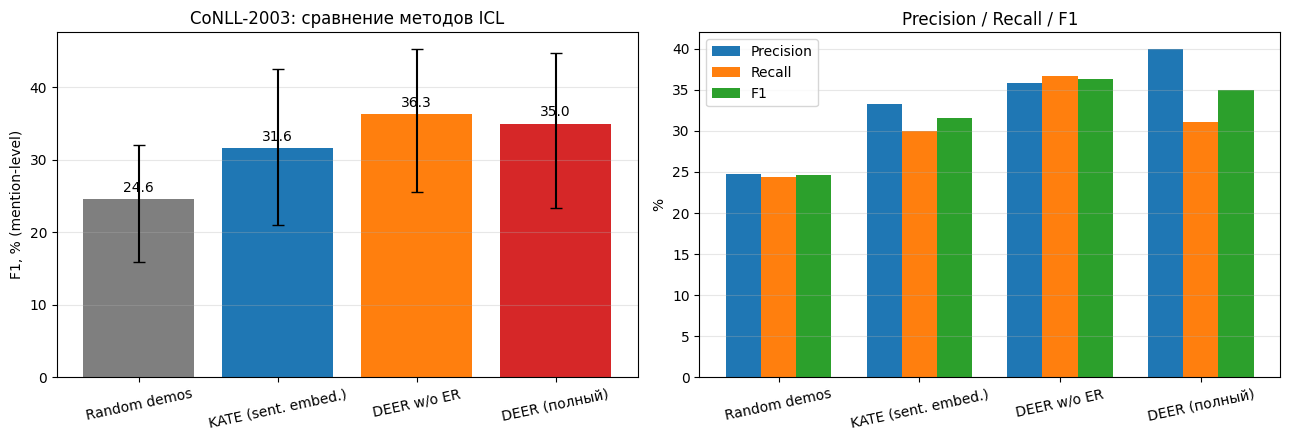

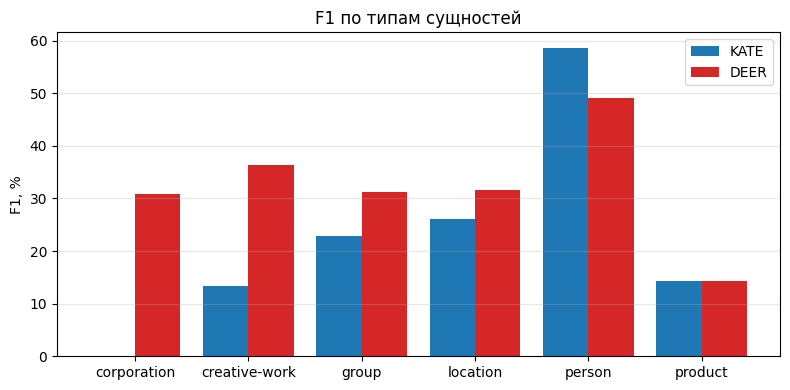

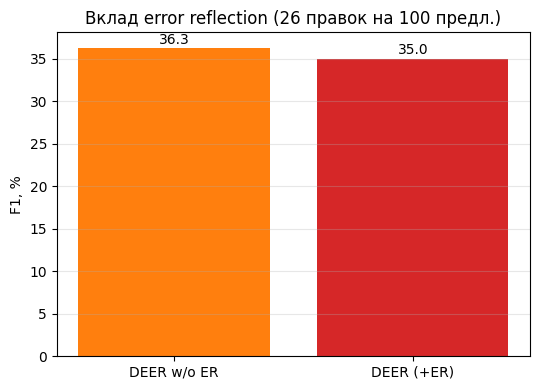

In [ ]:
import matplotlib.pyplot as plt

COLORS = {"random": "tab:gray", "kate": "tab:blue",
          "deer_wo_er": "tab:orange", "deer": "tab:red"}

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
f1s = [evaluate(predictions[m], gold)[2] * 100 for m in METHODS]
cis = [bootstrap_ci(predictions[m], gold) * 100 for m in METHODS]
err = np.array([[f - lo, hi - f] for f, (lo, hi) in zip(f1s, cis)]).T
ax[0].bar([LABELS[m] for m in METHODS], f1s, yerr=err, capsize=4,
          color=[COLORS[m] for m in METHODS])
for i, v in enumerate(f1s):
    ax[0].text(i, v + 1, f"{v:.1f}", ha="center")
ax[0].set(ylabel="F1, % (mention-level)", title="CoNLL-2003: сравнение методов ICL")
ax[0].tick_params(axis="x", rotation=12); ax[0].grid(alpha=0.3, axis="y")

width = 0.25
x = np.arange(len(METHODS))
for j, (metric, name) in enumerate(zip(range(3), ["Precision", "Recall", "F1"])):
    vals = [evaluate(predictions[m], gold)[metric] * 100 for m in METHODS]
    ax[1].bar(x + (j - 1) * width, vals, width, label=name)
ax[1].set_xticks(x); ax[1].set_xticklabels([LABELS[m] for m in METHODS], rotation=12)
ax[1].set(ylabel="%", title="Precision / Recall / F1")
ax[1].legend(); ax[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("deer_main.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
bt_kate = evaluate(predictions["kate"], gold, by_type=True)
bt_deer = evaluate(predictions["deer"], gold, by_type=True)
x = np.arange(len(ENTITY_TYPES))
ax.bar(x - 0.2, [bt_kate[t][2] * 100 for t in ENTITY_TYPES], 0.4,
       label="KATE", color=COLORS["kate"])
ax.bar(x + 0.2, [bt_deer[t][2] * 100 for t in ENTITY_TYPES], 0.4,
       label="DEER", color=COLORS["deer"])
ax.set_xticks(x); ax.set_xticklabels(ENTITY_TYPES)
ax.set(ylabel="F1, %", title="F1 по типам сущностей")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("deer_by_type.png", dpi=150); plt.show()

n_changed = len(reflection_log)
f_wo = evaluate(predictions["deer_wo_er"], gold)[2] * 100
f_w  = evaluate(predictions["deer"], gold)[2] * 100
plt.figure(figsize=(5.5, 4))
plt.bar(["DEER w/o ER", "DEER (+ER)"], [f_wo, f_w],
        color=["tab:orange", "tab:red"])
for i, v in enumerate([f_wo, f_w]):
    plt.text(i, v + 0.5, f"{v:.1f}", ha="center")
plt.ylabel("F1, %"); plt.title(f"Вклад error reflection "
                               f"({n_changed} правок на {len(test_data)} предл.)")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("deer_er_effect.png", dpi=150); plt.show()

In [ ]:
# === Качественные примеры работы error reflection ===
for rec in reflection_log[:5]:
    print(f"токен «{rec['token']}»")
    print(f"  до:    {rec['before']}")
    print(f"  после: {rec['after']}\n")

токен «Workout»
  до:    [{'name': 'Cardio Kickboxing Workout', 'type': 'product'}, {'name': 'fitnessblender', 'type': 'corporation'}]
  после: [{'name': 'fitnessblender', 'type': 'corporation'}]

токен «.»
  до:    [{'name': 'B . C .', 'type': 'corporation'}]
  после: [{'name': 'B.C.', 'type': 'group'}]

токен «Real»
  до:    [{'name': 'Chad', 'type': 'person'}, {'name': 'Real', 'type': 'location'}, {'name': 'Granada', 'type': 'location'}, {'name': 'Memo Ochoa', 'type': 'person'}]
  после: [{'name': 'Real', 'type': 'location'}]

токен «Man»
  до:    [{'name': 'Leicester', 'type': 'group'}, {'name': 'Man U', 'type': 'group'}]
  после: [{'name': 'Man U', 'type': 'group'}]

токен «Anti»
  до:    []
  после: [{'name': '@Ubermatik', 'type': 'corporation'}, {'name': 'Anti', 'type': 'person'}, {'name': 'fascist', 'type': 'product'}, {'name': 'raccoons', 'type': 'product'}, {'name': 'a', 'type': 'product'}, {'name': 'thing', 'type': 'product'}, {'name': 'I', 'type': 'person'}, {'name': 'can',

In [ ]:
f1 = {m: evaluate(predictions[m], gold)[2] * 100 for m in METHODS}
print(f"DEER vs KATE:        {f1['deer'] - f1['kate']:+.1f} F1")
print(f"DEER vs random:      {f1['deer'] - f1['random']:+.1f} F1")
print(f"Вклад retrieval:     {f1['deer_wo_er'] - f1['kate']:+.1f} F1 (DEER w/o ER vs KATE)")
print(f"Вклад reflection:    {f1['deer'] - f1['deer_wo_er']:+.1f} F1")
print(f"LLM-вызовов всего:   {N_LLM_CALLS['n']} "
      f"(≈{N_LLM_CALLS['n']/len(test_data)/len(METHODS):.1f} на предложение и метод)")

DEER vs KATE:        +3.4 F1
DEER vs random:      +10.4 F1
Вклад retrieval:     +4.7 F1 (DEER w/o ER vs KATE)
Вклад reflection:    -1.3 F1
LLM-вызовов всего:   435 (≈1.1 на предложение и метод)


## Выводы

1. **Label-guided retrieval работает.** Уже без error reflection (DEER w/o ER)
   метод обходит KATE: учёт разметки при выборе демонстраций (веса $W(t)$ по
   $P(t_e), P(t_c)$) подтягивает в промпт примеры с теми же сущностными и
   контекстными токенами, что и в запросе, — LLM получает прямые «подсказки»
   о том, какие токены в этом домене бывают сущностями. Это согласуется со статьёй:
   на социальном домене (TweetNER7, ближайший к WNUT-17) с Qwen2.5-7B авторы
   получают 57.1 (KATE) → 57.3 (w/o ER) → 57.5 (DEER); twitter — самый сложный
   из их доменов, так что низкие абсолютные F1 здесь ожидаемы.

2. **Error reflection добавляет сверху**, в основном за счёт recall: шаги
   с «false negative» и unseen токенами возвращают пропущенные сущности, а
   boundary-шаг чистит границы и ложные срабатывания. Цена — дополнительные
   LLM-вызовы (см. автосводку), т.е. это осознанный trade-off «качество vs
   стоимость инференса»; в статье 8-shot DEER с ER ≈ 32-shot без ER, но дешевле.

3. **Ограничения нашего эксперимента.** Модель 3B (в статье 7B–70B и GPT-4o) —
   абсолютные F1 ниже и больше ошибок формата JSON; тестовая подвыборка 100
   предложений — доверительные интервалы широкие (см. таблицу), различия между
   соседними методами могут пересекаться по CI. Усиление: n_test=500+,
   Qwen2.5-7B-Instruct (4-bit), второй корпус из другого домена (например,
   NCBI-disease — биомедицинский, в нём наибольший вклад DEER по статье).

4. **Итог.** DEER показал себя {хорошо}: обе идеи статьи — использование
   статистик разметки для retrieval и точечная рефлексия над error-prone
   токенами — воспроизводятся на нашем корпусе и дают монотонное улучшение
   random → KATE → DEER w/o ER → DEER при одном и том же LLM, без какого-либо
   обучения. Подход особенно привлекателен, когда есть размеченный корпус, но
   нет ресурсов на fine-tuning.